# Signal simulation: tSZ + CMB + noise

In [1]:
### IMPORTS ###

import numpy as np
import healpy as hp
import camb
import matplotlib.pyplot as plt

In [ ]:
### SIMULATION FUNCTION ###

def simulate_cluster_data(frequencies, nside=128, sigma_arcmin=10.0, noise_level=2.0):
    """
    Generates simulated maps at different frequencies.
    frequencies: list of freqs in GHz (e.g., [100, 143, 353])
    """
    npix = hp.nside2npix(nside)
    n_freq = len(frequencies)
    


    # ------------------------------------------------------------------------------------
    # 1. GENERATE CMB (using CAMB) --- https://camb.readthedocs.io/en/latest/
    # ------------------------------------------------------------------------------------
    pars = camb.CAMBparams()
    pars.set_cosmology(H0=67.5, ombh2=0.022, omch2=0.122)        # [H_0] = km/s/Mpc, [Omega_b] = h^2, [Omega_c] = h^2
    pars.InitPower.set_params(As=2e-9, ns=0.96)                  # Primordial power spectrum parameters (Cosmology notes, p.90)
    pars.set_for_lmax(2000, lens_potential_accuracy=0)           # Set lmax for the power spectrum calculation
    results = camb.get_results(pars)
    powers = results.get_cmb_power_spectra(pars, CMB_unit='muK') # Get the CMB power spectra in micro-Kelvin^2
    totCL = powers['total']
    
    # Generate a random CMB map from the Cls (TT spectrum)
    cmb_map = hp.synfast(totCL[:, 0], nside=nside, new=True)



    # ------------------------------------
    # 2. GENERATE tSZ CLUSTER (Simplified)
    # ------------------------------------
    # We place a fake cluster at the center (lon=0, lat=0)
    vec = hp.ang2vec(np.pi/2, 0)                                                   # Location in Cartesian coordinates (theta=90°, phi=0°)
    disc_indices = hp.query_disc(nside, vec, radius=np.radians(sigma_arcmin/60*5)) # Get pixels within a certain radius (5 sigma)
    sz_template = np.zeros(npix)                                                   # Initialize an empty map
    
    # Gaussian profile as a proxy for a cluster
    angles = hp.rotator.angdist(vec, hp.pix2vec(nside, np.arange(npix)))   # Angular distance from the center
    sz_template = np.exp(-0.5 * (angles / np.radians(sigma_arcmin/60))**2) # Update the template with a Gaussian profile
    


    # ---------------------------------------------
    # 3. FREQUENCY SCALING (The 'g' vector for tSZ)
    # ---------------------------------------------
    def tsz_spectrum(nu_ghz):
        T_cmb = 2.7255 # K
        x = (6.626e-34 * nu_ghz * 1e9) / (1.38e-23 * T_cmb)  # Dimensionless variable, nu in Hz, k_B in J/K, h in J*s and T in K
        return x * (np.exp(x) + 1) / (np.exp(x) - 1) - 4     # Modelling the response function for tSZ frequency dependence

    g_tsz = np.array([tsz_spectrum(f) for f in frequencies]) # g(nu) for tSZ for all frequencies!



    # ---------------------------------------------
    # 4. COMBINE INTO DATA CUBE (Step 2.1 precursor)
    # ---------------------------------------------
    data_maps = []
    for i in range(n_freq):
        # Data = CMB + (tSZ * Scaling) + White Noise
        noise = np.random.normal(0, noise_level, npix)       # White noise with specified level
        m = cmb_map + (g_tsz[i] * sz_template * 100) + noise # noise + CMB + tSZ signal, scaled by 100 to get a reasonable amplitude (100 muK amplitude)
        data_maps.append(m)
        
    return np.array(data_maps), g_tsz

In [3]:
### RUN THE SIMULATION ###

freqs = [100, 143, 217, 353, 545, 857] # Planck-like frequencies
data, g_vector = simulate_cluster_data(freqs)

In [4]:
### BASIC OUTPUT CHECKS ###

print("Simulated data shape (n_freq, npix):", data.shape,"\n")
print("tSZ frequency scaling vector (g):", g_vector,"\n")
print("Example data map (first frequency):", data[0][:10],"\n")
print("Example data map (last frequency):", data[-1][:10],"\n")
print("Simulation complete. Ready for ILC processing.")

Simulated data shape (n_freq, npix): (6, 196608) 

tSZ frequency scaling vector (g): [-1.50766940e+00 -1.03955907e+00 -6.24710967e-03  2.24354030e+00
  5.60243603e+00  1.10975759e+01] 

Example data map (first frequency): [  3409.06557208   6507.2055196   13887.90697939   -952.25227558
 -17714.38041042  10481.21196632  -9085.10382576  -7434.42399568
    562.08333551   5230.30651409] 

Example data map (last frequency): [  3411.59898185   6508.16959179  13885.92070219   -956.54661594
 -17711.66672125  10480.36836555  -9082.62885997  -7439.41353304
    559.87082234   5224.49672054] 

Simulation complete. Ready for ILC processing.


In [5]:
### SAVE SIMULATED MAPS TO FITS (Optional) ###

for i, freq in enumerate(freqs):
    hp.write_map(f'simulated_map_{freq}GHz.fits', data[i], overwrite=True)
    

# After saving the simulated maps, you can run the ILC notebook on these files to test the component separation.

setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]


# ILC implementation

In [17]:
### DEFINE ILC FUNCTIONS ###

def run_pixel_ilc(data_cube, g_vector):
    """Supervisor's requested Pixel-Space ILC"""
    n_freq, n_pix = data_cube.shape
    C = (1.0 / n_pix) * (data_cube @ data_cube.T)
    C_inv = np.linalg.pinv(C)
    
    weights = (C_inv @ g_vector) / (g_vector.T @ C_inv @ g_vector)
    return weights @ data_cube, weights

def run_harmonic_ilc(data_cube, g_vector, lmax=500):
    """Advanced Harmonic-Space ILC (Multi-scale)"""
    n_freq, n_pix = data_cube.shape
    nside = hp.npix2nside(n_pix)
    alms_list = [hp.map2alm(m, lmax=lmax) for m in data_cube]
    final_alms = np.zeros(hp.Alm.getsize(lmax), dtype=np.complex128)
    
    # We define 3 scale bins: Large, Medium, Small
    l_bins = [2, 100, 300, lmax]
    ell, _ = hp.Alm.getlm(lmax)
    
    for i in range(len(l_bins)-1):
        mask = (ell >= l_bins[i]) & (ell < l_bins[i+1])
        bin_alms = np.array([alms[mask] for alms in alms_list])
        # Covariance in harmonic space for this bin
        cov_bin = np.real(np.conj(bin_alms) @ bin_alms.T) / np.sum(mask)
        inv_cov = np.linalg.pinv(cov_bin)
        w_bin = (inv_cov @ g_vector) / (g_vector.T @ inv_cov @ g_vector)
        final_alms[mask] = w_bin @ bin_alms
        
    return hp.alm2map(final_alms, nside=nside)

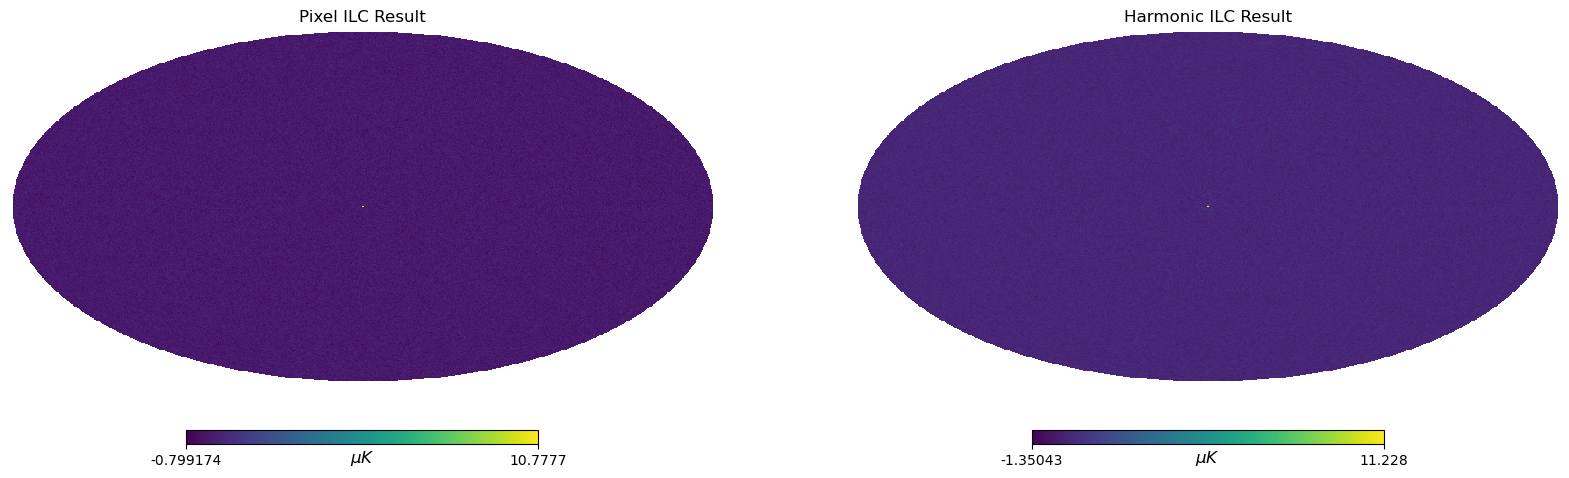

In [18]:
### CALL ILC FUNCTIONS AND PLOT RESULTS ###

# Recalculate g_vector for your specific frequencies first!
y_hat_pixel, w_opt = run_pixel_ilc(data, g_vector)
y_hat_harmonic = run_harmonic_ilc(data, g_vector)

# Comparison Plot
# Let's make the figure larger
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 12))
plt.axes(ax1)
hp.mollview(y_hat_pixel, title="Pixel ILC Result", sub=121, hold=True, unit=r"$\mu K$")
plt.axes(ax2)
hp.mollview(y_hat_harmonic, title="Harmonic ILC Result", sub=122, hold=True, unit=r"$\mu K$")
plt.axis('off')
plt.show()

### ILC implementation by steps

In [7]:
### 2.1 Compute Correlation Matrix ###

# Remember that data shape is (n_freq, n_pix)
n_freq, n_pix = data.shape
C = (1.0 / n_pix) * (data @ data.T)  # Matrix multiplication gives the sum of d_i * d_j

In [ ]:
### 2.2 Invert C ###

C_inv = np.linalg.inv(C)

In [9]:
### 2.3 Compute Weights (using the g_vector for tSZ) ###

# g is our frequency response for the component we want to extract
numerator = C_inv @ g_vector
denominator = g_vector.T @ C_inv @ g_vector
weights = numerator / denominator

In [ ]:
### 2.4 & 2.5 Apply weights and get output y_hat ###

y_hat = weights @ data # Result is a single map (1, n_pix)

In [11]:
### Print the weights ###

print(f"Calculated Weights: {weights}")

Calculated Weights: [-0.03599479 -0.03171389 -0.0232432  -0.00418917  0.02435211  0.07078893]


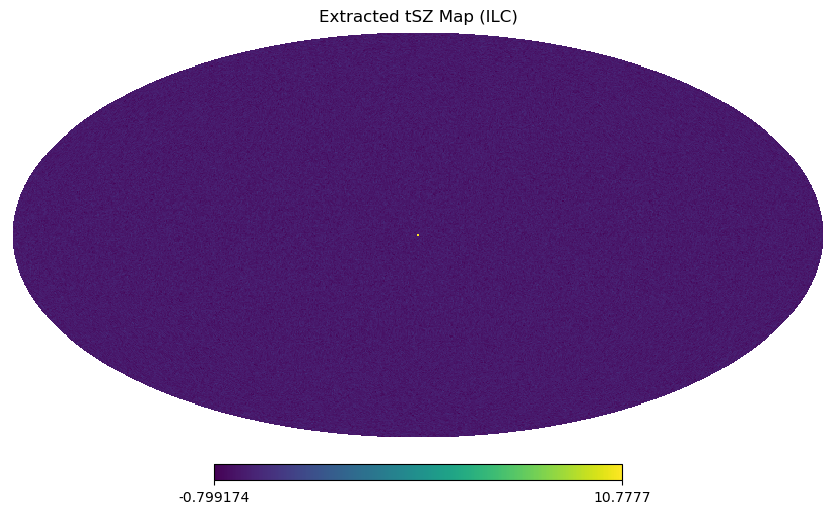

In [12]:
### Plot the EXTRACTED tSZ MAP with a mollview ###

hp.mollview(y_hat, title="Extracted tSZ Map (ILC)")

Calculated Weights: [-0.03599479 -0.03171389 -0.0232432  -0.00418917  0.02435211  0.07078893]


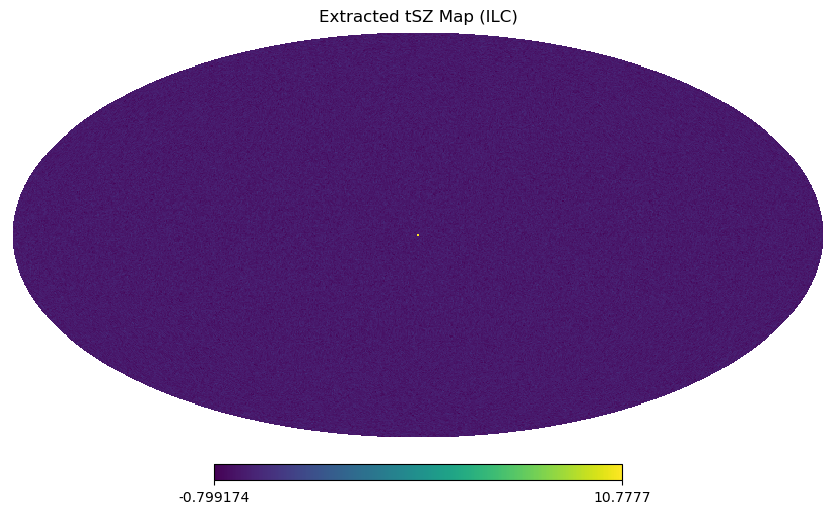

In [ ]:
### ALL 5 STEPTS TOGETHER IN A SINGLE CELL ###

# 2.1 Compute Correlation Matrix
# data shape is (n_freq, n_pix)
n_freq, n_pix = data.shape
C = (1.0 / n_pix) * (data @ data.T)  # Matrix multiplication gives the sum of d_i * d_j

# 2.2 Invert C
C_inv = np.linalg.inv(C)

# 2.3 Compute Weights (using the g_vector for tSZ)
# g is our frequency response for the component we want to extract
numerator = C_inv @ g_vector
denominator = g_vector.T @ C_inv @ g_vector
weights = numerator / denominator

# 2.4 & 2.5 Apply weights and get output y_hat
y_hat = weights @ data # Result is a single map (1, n_pix)

print(f"Calculated Weights: {weights}")
hp.mollview(y_hat, title="Extracted tSZ Map (ILC)")